In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.6 MB/s eta 0:00:00


In [2]:
from Bio import SeqIO

def process_and_summarize(filename, label, limit=500):
    # 1. file load
    all_records = list(SeqIO.parse(filename, "fasta"))

    # 2. Exactly 'limit' (500) sequences

    records = all_records[:limit]

    print(f"\n--- {label} ---")
    print(f"Total Sequences in File: {len(all_records)}")
    print(f"Sequences taken for Model: {len(records)}")

    if len(records) > 0:
        lengths = [len(r.seq) for r in records]
        print(f"Max Length: {max(lengths)} bp")
        print(f"Min Length: {min(lengths)} bp")
        print(f"Average Length: {sum(lengths)/len(records):.2f} bp")


        if len(records) < limit:
            print(f" Warning: File has less than {limit} sequences!")

    return records


pathogen_records = process_and_summarize("Agrobacterium.fasta", "Pathogen (Agrobacterium)", limit=500)
beneficial_records = process_and_summarize("Rhizobium.fasta", "Beneficial (Rhizobium)", limit=500)


# X = pathogen_records + beneficial_records


--- Pathogen (Agrobacterium) ---
Total Sequences in File: 501
Sequences taken for Model: 500
Max Length: 1517 bp
Min Length: 1365 bp
Average Length: 1413.69 bp

--- Beneficial (Rhizobium) ---
Total Sequences in File: 598
Sequences taken for Model: 500
Max Length: 1522 bp
Min Length: 1370 bp
Average Length: 1413.93 bp


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def fasta_to_df(filename, label):
    sequences = []
    for record in SeqIO.parse(filename, "fasta"):
        sequences.append(str(record.seq).upper()) # uppercase
    return pd.DataFrame({'sequence': sequences, 'class': label})

# Dataframes formation

df_bad = fasta_to_df("Agrobacterium.fasta", 1).iloc[:500] # Pathogen
df_good = fasta_to_df("Rhizobium.fasta", 0).iloc[:500] # Beneficial

# merge
df = pd.concat([df_bad, df_good]).reset_index(drop=True)

print("dataset ready")
print(df.head())

dataset ready
                                            sequence  class
0  GTTTGATCCTGGCTCAGAACGAACGCTGGCGGCAGGCTTAACACAT...      1
1  GCCGGGGCGGGAGCTACACATGCAGTCGAACGCCCCGCAAGGGGAG...      1
2  AGAGTTTGATCCTGGCTCAGAACGAACGCTGGCGGCAGGCTTAACA...      1
3  TAGAGTTTGATCTTGGCTCAGAACGAACGCTGGCGGCAGGCTTAAC...      1
4  TTTTGAGAGTTTTGTTCTGGCTCAGGACGAACGCTGGCGGCAGGCT...      1


In [4]:
# Label Mapping
# 0 = Beneficial (Rhizobium)
# 1 = Pathogen (Agrobacterium)


df['label_name'] = df['class'].map({0: 'Beneficial (Rhizobium)', 1: 'Pathogen (Agrobacterium)'})

print("Labeling Verification:")
print(df[['label_name', 'class']].drop_duplicates())
df.columns


Labeling Verification:
                   label_name  class
0    Pathogen (Agrobacterium)      1
500    Beneficial (Rhizobium)      0


Index(['sequence', 'class', 'label_name'], dtype='object')

In [5]:
 # set lower and upper limit of bp
# lower_limit = 1300
# upper_limit = 1500
#formation of length column
df['length'] = df['sequence'].apply(len)

# df_final = df[(df['length'] >= lower_limit) & (df['length'] <= upper_limit)].copy()
# Check for 'N' characters and clean if necessary
df['sequence'] = df['sequence'].str.replace('N', '')
print(df.columns)

# print(f"Total sequences within range ({lower_limit}-{upper_limit} bp): {len(df_final)}")
print(f"Agrobacterium (Pathogen): {len(df[df['class']==1])}")
print(f"Rhizobium (Benefactor): {len(df[df['class']==0])}")

Index(['sequence', 'class', 'label_name', 'length'], dtype='object')
Agrobacterium (Pathogen): 500
Rhizobium (Benefactor): 500


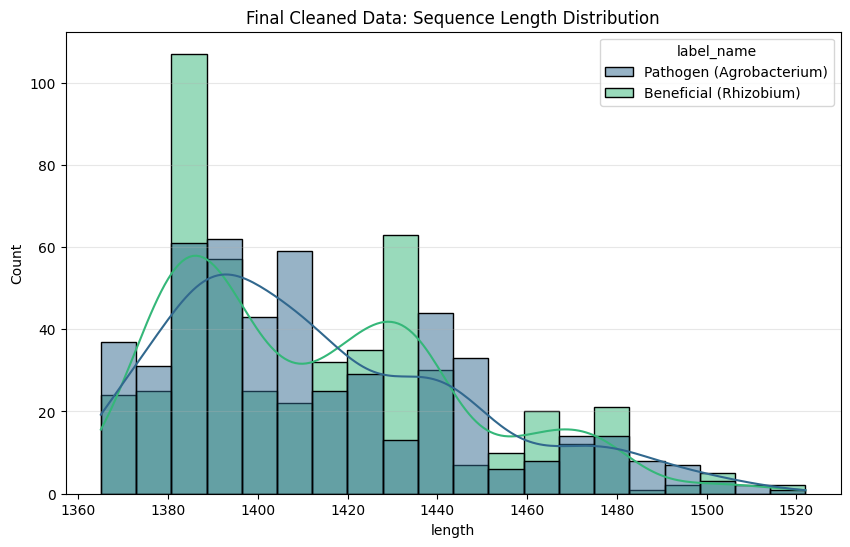

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='length', hue='label_name', kde=True, palette='viridis', bins=20)
plt.title('Final Cleaned Data: Sequence Length Distribution')
plt.grid(axis='y', alpha=0.3)
plt.show()

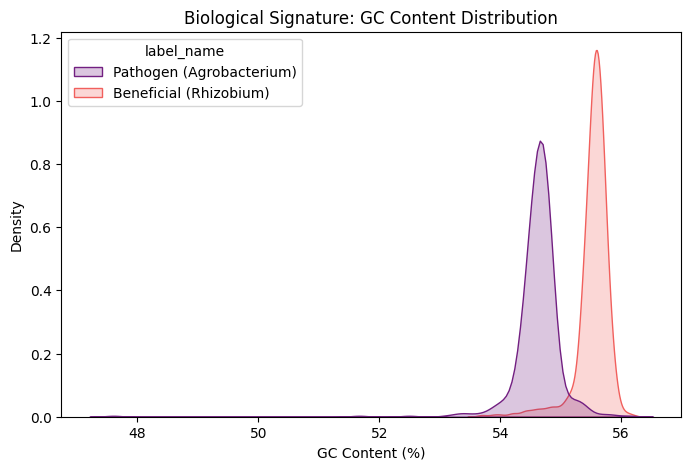

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# GC content calculation
def get_gc(seq):
    return (seq.count('G') + seq.count('C')) / len(seq) * 100

df['gc_content'] = df['sequence'].apply(get_gc)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='gc_content', hue='label_name', fill=True, palette='magma')
plt.title('Biological Signature: GC Content Distribution')
plt.xlabel('GC Content (%)')
plt.ylabel('Density')
plt.show()

In [8]:
df.head()

,sequence,class,label_name,length,gc_content
0,GTTTGATCCTGGCTCAGAACGAACGCTGGCGGCAGGCTTAACACAT...,1,Pathogen (Agrobacterium),1473,54.786151
1,GCCGGGGCGGGAGCTACACATGCAGTCGAACGCCCCGCAAGGGGAG...,1,Pathogen (Agrobacterium),1389,54.859611
2,AGAGTTTGATCCTGGCTCAGAACGAACGCTGGCGGCAGGCTTAACA...,1,Pathogen (Agrobacterium),1444,54.501385
3,TAGAGTTTGATCTTGGCTCAGAACGAACGCTGGCGGCAGGCTTAAC...,1,Pathogen (Agrobacterium),1440,54.375000
4,TTTTGAGAGTTTTGTTCTGGCTCAGGACGAACGCTGGCGGCAGGCT...,1,Pathogen (Agrobacterium),1411,54.487179


In [9]:
# 1. Define K-mer function
def getKmers(sequence, size=6):
    return [sequence[x:x+size].lower() for x in range(len(sequence) - size + 1)]

# 2. 'tokenization'
df['sentence'] = df.apply(lambda x: ' '.join(getKmers(x['sequence'])), axis=1)

# 3. check head
df[['label_name', 'sentence']].head()

,label_name,sentence
0,Pathogen (Agrobacterium),gtttga tttgat ttgatc tgatcc gatcct atcctg tcct...
1,Pathogen (Agrobacterium),gccggg ccgggg cggggc ggggcg gggcgg ggcggg gcgg...
2,Pathogen (Agrobacterium),agagtt gagttt agtttg gtttga tttgat ttgatc tgat...
3,Pathogen (Agrobacterium),tagagt agagtt gagttt agtttg gtttga tttgat ttga...
4,Pathogen (Agrobacterium),ttttga tttgag ttgaga tgagag gagagt agagtt gagt...


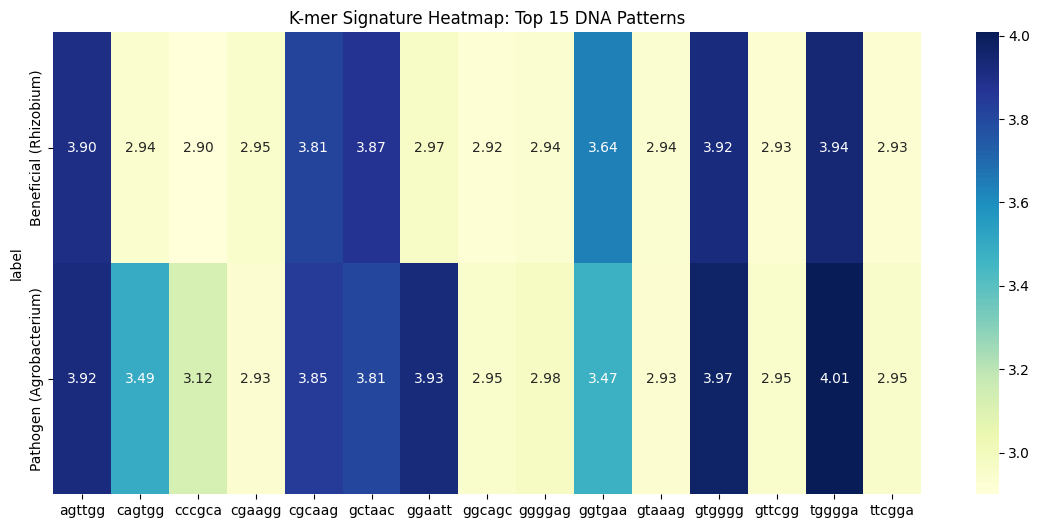

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. common 15 K-mers
cv = CountVectorizer(max_features=15)
X_counts = cv.fit_transform(df['sentence'])
words = cv.get_feature_names_out()

# 2. Average frequency  per class
counts_df = pd.DataFrame(X_counts.toarray(), columns=words)
counts_df['label'] = df['label_name'].values
heatmap_data = counts_df.groupby('label').mean()

# 3. Plotting
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt='.2f')
plt.title('K-mer Signature Heatmap: Top 15 DNA Patterns')
plt.show()

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd


# 1. Tf-Idf Vectorizer setup
tfidf = TfidfVectorizer(ngram_range=(1,2), analyzer='word' , sublinear_tf=True , use_idf=True , smooth_idf=True)

# 2. DNA patterns to numbers (vectors)
X_tfidf = tfidf.fit_transform(df['sentence'])


# 3.  (A, T, G, C  patterns)
feature_names = tfidf.get_feature_names_out()

print(f"Tf-Idf Matrix shape: {X_tfidf.shape}")
print(f"Total Unique K-mers found: {len(feature_names)}")

Tf-Idf Matrix shape: (1000, 16585)
Total Unique K-mers found: 16585


/tmp/ipykernel_3166/2002997085.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_tfidf.tfidf_score, y=df_tfidf.index, palette="viridis")


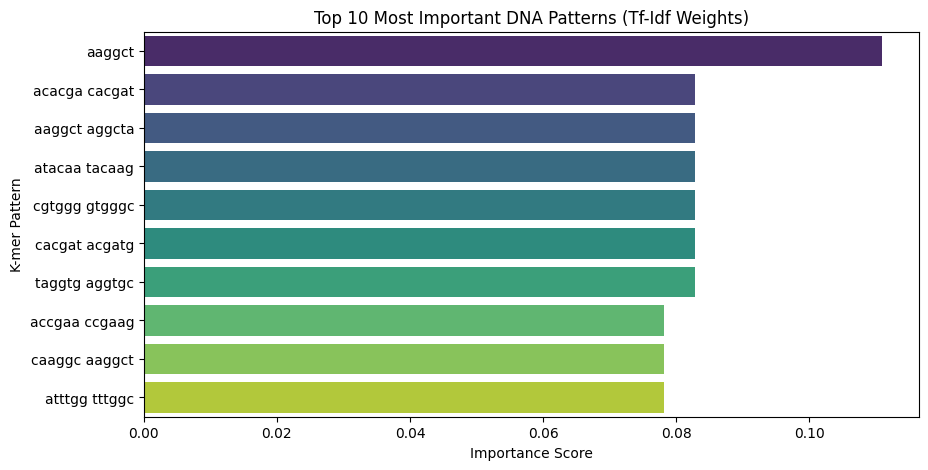

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# top 10 Tf-Idf scores
first_vector = X_tfidf[0]
df_tfidf = pd.DataFrame(first_vector.T.todense(), index=feature_names, columns=["tfidf_score"])
df_tfidf = df_tfidf.sort_values(by=["tfidf_score"], ascending=False).head(10)

# Plotting the Importance
plt.figure(figsize=(10, 5))
sns.barplot(x=df_tfidf.tfidf_score, y=df_tfidf.index, palette="viridis")
plt.title("Top 10 Most Important DNA Patterns (Tf-Idf Weights)")
plt.xlabel("Importance Score")
plt.ylabel("K-mer Pattern")
plt.show()

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

# list/dictionary of various  models
models = {
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (Linear)": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=300 , max_depth=10, random_state=10),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Tf-Idf Setup
tfidf = TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True) # sublinear_tf

# 2. define Data
X = df['sentence']
y = df['class'].values

# 3. Split (80% Training, 20% Testing)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Vectorization
X_train = tfidf.fit_transform(X_train_raw) # Training  fit
X_test = tfidf.transform(X_test_raw)       # Test transform

# print shape
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# 5. Model Training Loop
trained_models = {}
print("--- Training Starts ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name}: Training Complete!")

Training set size: 800
Testing set size: 200
--- Training Starts ---
Naive Bayes: Training Complete!
Logistic Regression: Training Complete!
SVM (Linear): Training Complete!
Random Forest: Training Complete!
KNN: Training Complete!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:59:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: Training Complete!


--- comparative result ---
              Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
      Random Forest          99.5      98.969072  100.000000     99.481865
       SVM (Linear)          99.5      98.969072  100.000000     99.481865
                KNN          99.5      98.969072  100.000000     99.481865
            XGBoost          99.5      98.969072  100.000000     99.481865
Logistic Regression          99.0      98.958333   98.958333     98.958333
        Naive Bayes          99.0      98.958333   98.958333     98.958333


/tmp/ipykernel_3166/4014240644.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy (%)', y='Model', data=performance_df, palette='magma')


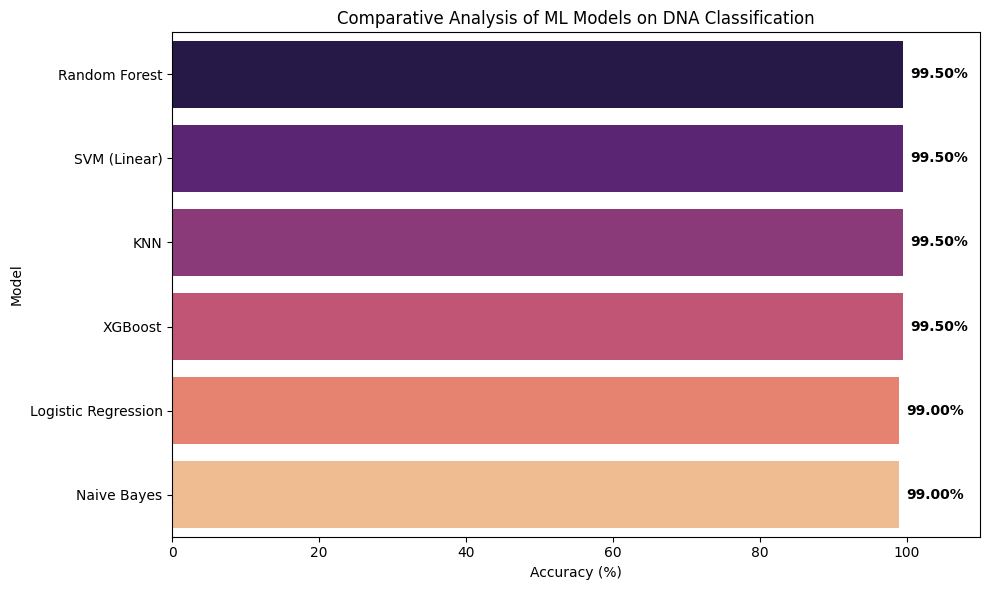

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate all 4 metrics in a loop
performance_data = []

for name, model in trained_models.items():
    # Prediction on Test data
    y_pred = model.predict(X_test)

    # Calculating all metrics
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred) * 100
    rec = recall_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100

    # Storing results in a list
    performance_data.append({
        'Model': name,
        'Accuracy (%)': acc,
        'Precision (%)': prec,
        'Recall (%)': rec,
        'F1-Score (%)': f1
    })

# 2. Convert to DataFrame and Sort
performance_df = pd.DataFrame(performance_data)
performance_df = performance_df.sort_values(by='Accuracy (%)', ascending=False)

print("--- comparative result ---")
print(performance_df.to_string(index=False))

# 3. Updated Visual Comparison (Grouped Bar Graph or updated Bar Chart)
plt.figure(figsize=(10, 6))

sns.barplot(x='Accuracy (%)', y='Model', data=performance_df, palette='magma')

plt.title('Comparative Analysis of ML Models on DNA Classification')
plt.xlim(0, 110) # Set to 110 to give space for text

for i, v in enumerate(performance_df['Accuracy (%)']):
    plt.text(v + 1, i, f"{v:.2f}%", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

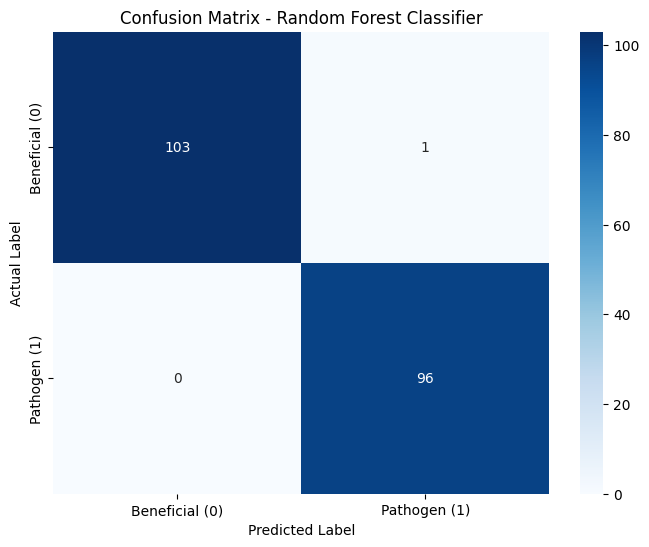


--- Detailed Analysis ---
Correctly identified Pathogens (True Positives): 96
Correctly identified Beneficial (True Negatives): 103
Pathogens missed by model (False Negatives): 0
Beneficial wrongly flagged as Pathogens (False Positives): 1


In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Random Forest se predictions
rf_model = trained_models['Random Forest']
y_pred_rf = rf_model.predict(X_test)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

# 3. Visualization using Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Beneficial (0)', 'Pathogen (1)'],
            yticklabels=['Beneficial (0)', 'Pathogen (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

# 4. Error Analysis (Optional)
tn, fp, fn, tp = cm.ravel()
print(f"\n--- Detailed Analysis ---")
print(f"Correctly identified Pathogens (True Positives): {tp}")
print(f"Correctly identified Beneficial (True Negatives): {tn}")
print(f"Pathogens missed by model (False Negatives): {fn}")
print(f"Beneficial wrongly flagged as Pathogens (False Positives): {fp}")

In [17]:
from sklearn.model_selection import cross_val_score
import numpy as np


cv_results = []

print("--- Starting 5-Fold Cross Validation ---")

for name, model in models.items():

    scores = cross_val_score(model, X_train, y_train, cv=5)

    avg_acc = scores.mean() * 100
    std_dev = scores.std()

    cv_results.append({
        'Model': name,
        'CV Avg Accuracy (%)': avg_acc,
        'Stability (Std Dev)': std_dev
    })

    print(f"{name}: Done! (Avg: {avg_acc:.2f}%)")

# 2. converting result to  DataFrame
cv_df = pd.DataFrame(cv_results).sort_values(by='CV Avg Accuracy (%)', ascending=False)

print("\n--- Final Stability Report ---")
print(cv_df.to_string(index=False))

# Interpretation Guide:
# 1.if Accuracy High and Std Dev (0.01 - 0.03) hai -> Model is Great!
# 2.if Accuracy High and Std Dev (> 0.05) hai -> Model is Unstable (Overfitting).

--- Starting 5-Fold Cross Validation ---
Naive Bayes: Done! (Avg: 98.12%)
Logistic Regression: Done! (Avg: 98.12%)
SVM (Linear): Done! (Avg: 99.25%)
Random Forest: Done! (Avg: 99.25%)
KNN: Done! (Avg: 98.75%)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:00:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:00:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:00:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:01:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost: Done! (Avg: 99.00%)

--- Final Stability Report ---
              Model  CV Avg Accuracy (%)  Stability (Std Dev)
      Random Forest               99.250             0.007289
       SVM (Linear)               99.250             0.007289
            XGBoost               99.000             0.008478
                KNN               98.750             0.003953
Logistic Regression               98.125             0.005590
        Naive Bayes               98.125             0.005590


Running Sensitivity Analysis across multiple seeds...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:01:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:02:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:02:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:02:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

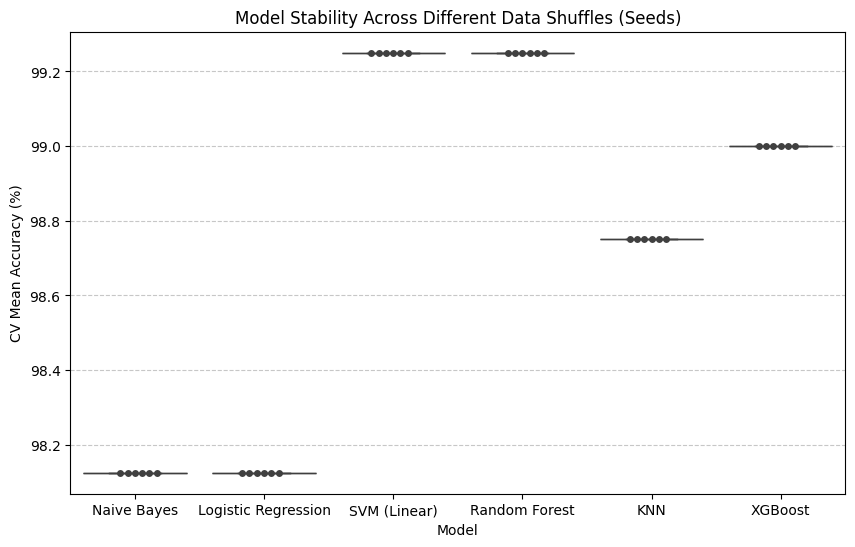


--- Stability Summary ---
                       mean  std     min     max
Model                                           
KNN                  98.750  0.0  98.750  98.750
Logistic Regression  98.125  0.0  98.125  98.125
Naive Bayes          98.125  0.0  98.125  98.125
Random Forest        99.250  0.0  99.250  99.250
SVM (Linear)         99.250  0.0  99.250  99.250
XGBoost              99.000  0.0  99.000  99.000


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sensitivity Analysis Loop ---
all_results = []
test_seeds = [42, 100, 123, 2024, 7, 99]

print("Running Sensitivity Analysis across multiple seeds...")

for seed in test_seeds:
    for name, model in models.items():
        # 5-Fold CV
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)
        all_results.append({
            "Seed": seed,
            "Model": name,
            "Accuracy": np.mean(cv_scores) * 100
        })

# DataFrame
results_df = pd.DataFrame(all_results)

# --- Visualization ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Accuracy', data=results_df)
sns.swarmplot(x='Model', y='Accuracy', data=results_df, color=".25")
plt.title('Model Stability Across Different Data Shuffles (Seeds)')
plt.ylabel('CV Mean Accuracy (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Final Summary Table
print("\n--- Stability Summary ---")
print(results_df.groupby("Model")["Accuracy"].agg(["mean", "std", "min", "max"]))

In [20]:
import joblib
from google.colab import files


joblib.dump(trained_models['Random Forest'], 'pathogen_model.pkl')
joblib.dump(tfidf, 'vectorizer.pkl')


files.download('pathogen_model.pkl')
files.download('vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import numpy as np

# 1. identify (Majority Class)
unique, counts = np.unique(y_test, return_counts=True)
majority_class_index = np.argmax(counts)
majority_class_count = counts[majority_class_index]

# 2. Baseline Accuracy Calculation
#
baseline_acc = (majority_class_count / len(y_test)) * 100

print(f"--- Baseline Analysis ---")
print(f"Total Test Samples: {len(y_test)}")
print(f"Majority Class Samples: {majority_class_count}")
print(f"Baseline Accuracy : {baseline_acc:.2f}%")

# 3. Model vs Baseline Comparison
model_acc = performance_df.iloc[0]['Accuracy (%)']
improvement = model_acc - baseline_acc

print(f"\nYour Model Accuracy: {model_acc:.2f}%")
print(f"Improvement over Baseline: {improvement:.2f}%")

--- Baseline Analysis ---
Total Test Samples: 200
Majority Class Samples: 104
Baseline Accuracy : 52.00%

Your Model Accuracy: 99.50%
Improvement over Baseline: 47.50%


In [23]:
#@title 16S rRNA Bacterial Sequence Predictor { run: "auto" }
import joblib

# 1. paste DNA sequence
Sequence_Input = "CAACTTGAGAGTTTGATCCTGGCTCAGAACGAACGCTGGCGGCAGGCTTAACACATGCAAGTCGAACGCC CCGCAAGGGGAGTGGCAGACGGGTGAGTAACGCGTGGGAATCTACCGTGCCCTGCGGAATAGCTCCGGGA AACTGGAATTAATACCGCATACGCCCTACGGGGGAAAGATTTATCGGGGTATGATGAGCCCGCGTTGGAT TAGCTAGTTGGTGGGGTAAAGGCCTACCAAGGCGACGATCCATAGCTGGTCTGAGAGGATGATCAGCCAC ATTGGGACTGAGACACGGCCCAAACTCCTACGGGAGGCAGCAGTGGGGAATATTGGACAATGGGCGCAAG CCTGATCCAGCCATGCCGCGTGAGTGATGAAGGCCTTAGGGTTGTAAAGCTCTTTCACCGGAGAAGATAA TGACGGTATCCGGAGAAGAAGCCCCGGCTAACTTCGTGCCAGCAGCCGCGGTAATACGAAGGGGGCTAGC GTTGTTCGGAATTACTGGGCGTAAAGCGCACGTAGGCGGATATTTAAGTCAGGGGTGAAATCCCAGAGCT CAACTCTGGAACTGCCTTTGATACTGGGTATCTTGAGTATGGAAGAGGTAAGTGGAATTCCGAGTGTAGA GGTGAAATTCGTAGATATTCGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGTCCATTACTGACGCTGA GGTGCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTCCACGCCGTAAACGATGAATGTTAG CCGTCGGGCAGTATACTGTTCGGTGGCGCAGCTAACGCATTAAACATTCCGCCTGGGGAGTACGGTCGCA AGATTAAAACTCAAAGGAATTGACGGGGGCCCGCACAAGCGGTGGAGCATGTGGTTTAATTCGAAGCAAC GCGCAGAACCTTACCAGCTCTTGACATTCGGGGTTTGGGCAGTGGAGACATTGTCCTTCAGTTAGGCTGG CCCCAGAACAGGTGCTGCATGGCTGTCGTCAGCTCGTGTCGTGAGATGTTGGGTTAAGTCCCGCAACGAG CGCAACCCTCGCCCTTAGTTGCCAGCATTTAGTTGGGCACTCTAAGGGGACTGCCGGTGATAAGCCGAGA GGAAGGTGGGGATGACGTCAAGTCCTCATGGCCCTTACGGGCTGGGCTACACACGTGCTACAATGGTGGT GACAGTGGGCAGCGAGACAGCGATGTCGAGCTAATCTCCAAAAGCCATCTCAGTTCGGATTGCACTCTGC AACTCGAGTGCATGAAGTTGGAATCGCTAGTAATCGCAGATCAGCATGCTGCGGTGAATACGTTCCCGGG CCTTGTACACACCGCCCGTCACACCATGGGAGTTGGTTTTACCCGAAGGTAGTGCGCTAACCGCAAGGAG GCAGCTAACCACGGTAGGGTCAGCGACTGGGGTGAAGTCGTAACAAGGTAGCCGTAGGGGAACCTGCGGC TGGATCACCTCCTTT" #@param {type:"string"}

# 2. load saved model & vectorizer

try:
    model = joblib.load('pathogen_model.pkl')
    tfidf = joblib.load('vectorizer.pkl')

    # 3.processing and predicting Input sequence

    processed_input = tfidf.transform([Sequence_Input])
    prediction = model.predict(processed_input)

    # 4. Result
    print("\n" + "="*40)
    print("         PREDICTION RESULT         ")
    print("="*40)
    if prediction[0] == 1:
        print(f"Result: PATHOGENIC BACTERIA ⚠️")
        print("Description: This strain shows high genomic similarity to soil-borne pathogens.")
    else:
        print(f"Result: BENEFICIAL BACTERIA 🌱")
        print("Description: This strain is classified as a growth-promoting or beneficial soil microbe.")
    print("="*40)

except FileNotFoundError:
    print("Error: 'predictor.joblib' ya 'vectorizer.joblib' file nahi mili.")
    print("Kripya pehle model training wale cells ko run karke files generate karein.")


         PREDICTION RESULT         
Result: PATHOGENIC BACTERIA ⚠️
Description: This strain shows high genomic similarity to soil-borne pathogens.
